In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
from pathlib import Path
from skimage.feature import hog
from skimage import exposure
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

DATA_DIR = Path("data/segments/labeled")
IMG_SIZE = (64, 64)  # resize all crops to this before feature extraction

In [2]:
# Load images from labeled folder structure
images, labels = [], []
class_counts = {}

for class_dir in sorted(DATA_DIR.iterdir()):
    if not class_dir.is_dir():
        continue
    files = list(class_dir.glob("*.png"))
    class_counts[class_dir.name] = len(files)
    if len(files) == 0:
        print(f"  ⚠ Skipping '{class_dir.name}' — no images")
        continue
    for fpath in files:
        img = cv.imread(str(fpath), cv.IMREAD_GRAYSCALE)
        img = cv.resize(img, IMG_SIZE)
        images.append(img)
        labels.append(class_dir.name)

print("Class distribution:")
for cls, n in class_counts.items():
    print(f"  {cls}: {n} images")
print(f"\nTotal loaded: {len(images)} images, {len(set(labels))} classes")

  ⚠ Skipping 'chain' — no images
  ⚠ Skipping 'double' — no images
Class distribution:
  chain: 0 images
  double: 0 images
  slip_stitch: 16 images
  treble: 33 images

Total loaded: 49 images, 2 classes


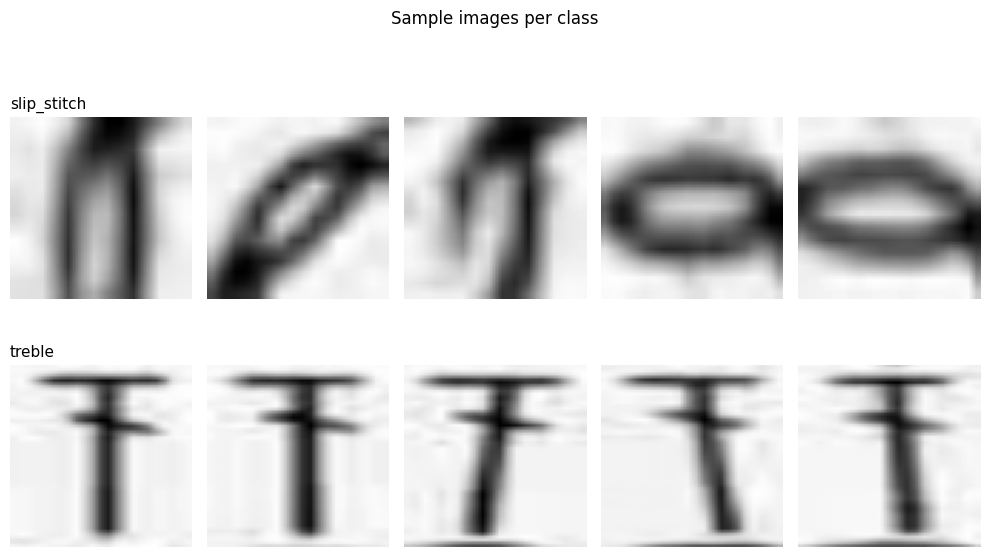

In [3]:
# Visualise a few samples per class
classes = sorted(set(labels))
fig, axes = plt.subplots(len(classes), 5, figsize=(10, 3 * len(classes)))
for row, cls in enumerate(classes):
    cls_imgs = [img for img, lbl in zip(images, labels) if lbl == cls]
    for col in range(5):
        ax = axes[row][col] if len(classes) > 1 else axes[col]
        if col < len(cls_imgs):
            ax.imshow(cls_imgs[col], cmap='gray')
        ax.axis('off')
        if col == 0:
            ax.set_title(cls, fontsize=11, loc='left')
plt.suptitle("Sample images per class", y=1.01)
plt.tight_layout()
plt.show()

Feature vector shape: (49, 1764)
Classes: [np.str_('slip_stitch'), np.str_('treble')]


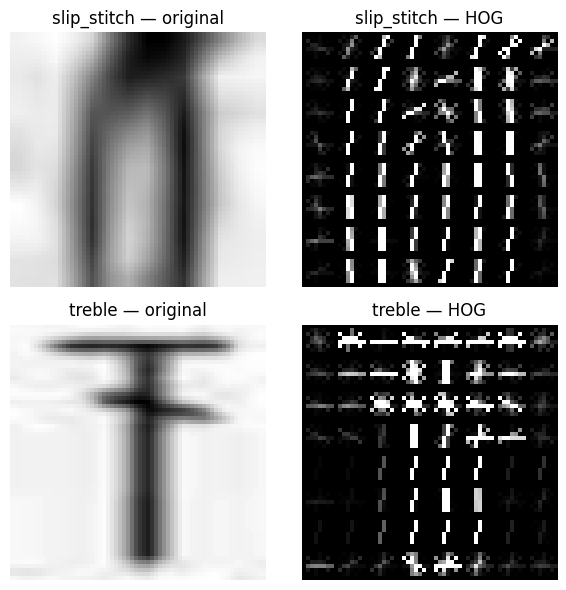

In [4]:
# Extract HOG features
# HOG captures gradients and edge directions — great for distinguishing
# elongated stitches (treble) from rounded shapes (slip stitch)
def extract_hog(img):
    features, hog_img = hog(
        img,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        visualize=True,
        channel_axis=None
    )
    return features, hog_img

X = np.array([extract_hog(img)[0] for img in images])
le = LabelEncoder()
y = le.fit_transform(labels)

print(f"Feature vector shape: {X.shape}")
print(f"Classes: {list(le.classes_)}")

# Visualise HOG for one sample per class
fig, axes = plt.subplots(len(classes), 2, figsize=(6, 3 * len(classes)))
for row, cls in enumerate(classes):
    idx = next(i for i, lbl in enumerate(labels) if lbl == cls)
    _, hog_img = extract_hog(images[idx])
    hog_rescaled = exposure.rescale_intensity(hog_img, in_range=(0, 10))
    axes[row][0].imshow(images[idx], cmap='gray');  axes[row][0].set_title(f"{cls} — original"); axes[row][0].axis('off')
    axes[row][1].imshow(hog_rescaled, cmap='gray'); axes[row][1].set_title(f"{cls} — HOG");      axes[row][1].axis('off')
plt.tight_layout()
plt.show()

In [5]:
# Train / test split — stratified to keep class ratio balanced in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train)} samples | Test: {len(X_test)} samples")

# SVM with RBF kernel — works well on HOG features
# Pipeline includes StandardScaler since SVM is sensitive to feature scale
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced', probability=True))
])
pipeline.fit(X_train, y_train)
print("Training complete.")

Train: 39 samples | Test: 10 samples
Training complete.


In [6]:
# Cross-validation on full dataset — more reliable than a single split given small N
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
print(f"5-fold CV accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(f"Per-fold:           {np.round(cv_scores, 3)}")

5-fold CV accuracy: 0.960 ± 0.049
Per-fold:           [0.9 1.  0.9 1.  1. ]


              precision    recall  f1-score   support

 slip_stitch       0.75      1.00      0.86         3
      treble       1.00      0.86      0.92         7

    accuracy                           0.90        10
   macro avg       0.88      0.93      0.89        10
weighted avg       0.93      0.90      0.90        10



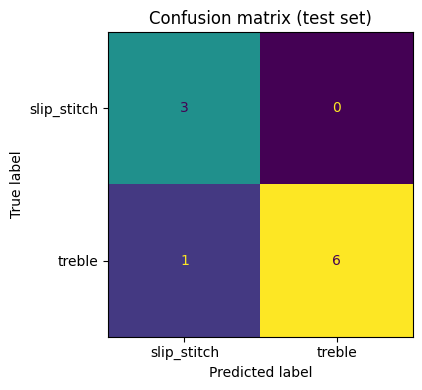

In [7]:
# Evaluate on hold-out test set
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le.classes_))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=le.classes_, ax=ax, colorbar=False)
plt.title("Confusion matrix (test set)")
plt.tight_layout()
plt.show()

1 misclassified sample(s):


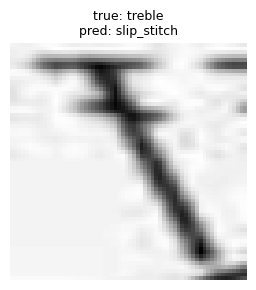

In [8]:
# Show misclassified samples — useful for understanding failure modes
test_indices = np.where(y_pred != y_test)[0]
if len(test_indices) == 0:
    print("No misclassifications on the test set!")
else:
    print(f"{len(test_indices)} misclassified sample(s):")
    fig, axes = plt.subplots(1, len(test_indices), figsize=(3 * len(test_indices), 3))
    if len(test_indices) == 1:
        axes = [axes]
    # Recover original test images
    _, X_test_imgs, _, _ = train_test_split(images, y, test_size=0.2, random_state=42, stratify=y)
    for ax, idx in zip(axes, test_indices):
        ax.imshow(X_test_imgs[idx], cmap='gray')
        ax.set_title(f"true: {le.classes_[y_test[idx]]}\npred: {le.classes_[y_pred[idx]]}", fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

In [9]:
import joblib

joblib.dump({"pipeline": pipeline, "label_encoder": le}, "model.joblib")
print("Model saved to model.joblib")

Model saved to model.joblib
